### Cell 0

`numpy`, `matplotlib`, `scipy.optimize.curve_fit` などを読み込んでいます。

- `numpy`: 数値計算
- `matplotlib`: グラフ描画
- `curve_fit`: 測定データをガウシアンビーム式にフィット
- `newton`: 後半で方程式を数値的に解くときに使う準備

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import newton
#from scipy.misc import derivative

### Cell 1

Sellmeier 式を定義して、ガラスの屈折率を波長から計算できるようにしています。

ここでやっていること:

- `sellmeier(lam)` で屈折率 `n` を計算
- 波長に対する屈折率の変化をグラフで確認

意味:

- レンズやガラスを含む光学系では、屈折率が分かると光の振る舞いを見積もれます。
- このセルは、後で使うガラスのパラメータ確認です。

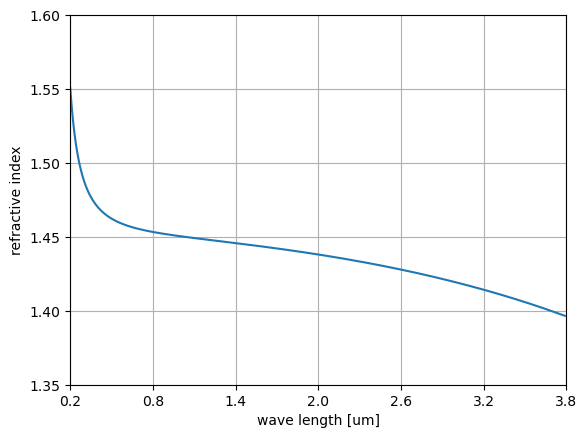

In [3]:
#Sellemeier Equation
def sellmeier(lam):
    return np.sqrt(1+0.6961663*lam**2/(lam**2-0.0684043**2)+0.4079426*lam**2/(lam**2-0.1162414**2)+0.8974794*lam**2/(lam**2-9.896161**2))

lam_list = np.arange(0.2,3.8,0.01) # [um]
plt.plot(lam_list,sellmeier(lam_list))
plt.xlim(0.2,3.8)
plt.ylim(1.35,1.60)
plt.xticks(np.arange(0.2,3.81,0.6))
plt.xlabel("wave length [um]")
plt.ylabel("refractive index")
plt.grid(True)

### Cell 2

解析に使う基本パラメータを定義しています。

主な値:

- `lam = 852.3e-9`
  Cs D2 線に近い波長で、MOT でよく使う波長帯です。
- `ng`, `nv`
  ガラスの屈折率
- `Rg`
  曲率半径
- `Lg`
  レンズ厚み

意味:

- このセルは「以降の計算で共通に使う物理定数の設定」です。

In [4]:
#parameter
lam = 852.3e-9 # wave length[m]
lam_sellmeier = 0.8523 # wave length[um]
ng = 1.517 # refractive index of glass
nv = sellmeier(lam_sellmeier)
print("refractive index of glass:", nv)
Rg = 75e-3 # curvature radius[m]
Lg = 5e-3 # tickness of lens[m] 

refractive index of glass: 1.4524625769508137


### Cell 3

共振器の安定条件と、その中でできるビームウェストを計算しています。

やっていること:

- ABCD 行列で共振器を表現
- `stabCal(L, R, lam)` で
  - 共振器内の曲率半径
  - 共振器ウェスト
  を計算

意味:

- 発振器や光学素子の前段条件をざっくり見積もるセルです。
- このノート全体の主役は後半の伝搬計算ですが、その前提確認として置かれています。

In [5]:
#stability condition

def stabCal(L,R,lam): 
    ML = np.array([[1,L],[0,1]]) #Lcavだけ直進
    MR = np.array([[1,0],[-2/R,1]]) #曲面鏡での反射

    M = np.matmul(MR,ML)
    M = np.matmul(ML,M)

    A=M[0][0]
    B=M[0][1]
    C=M[1][0]
    D=M[1][1]

    
    if D-A==0:
        R_cav = np.inf
    else:
        R_cav = 2*B/(D - A)
    w_cav = np.sqrt(2*B*lam/(np.pi*np.sqrt(4-(A+D)**2)))
    return R_cav, w_cav

R_cav, w_cav = stabCal(Lg,Rg,lam)
print(f"R_cav = {R_cav} [m]")
print(f"waist_cav = {w_cav*1e6:.2f} [um]")

R_cav = inf [m]
waist_cav = 71.24 [um]


# ↓ここからはじめた(川満)

# ビームパラメータの推定

ビームパラメータを求める（ビームウェイスト、ウェイスト位置、レイリー長を計算）、5点プロットし、Gaussianフィッティングを行う。サンプルはなるべくウェイスト位置に近いところをとると良い。

--- X方向 ---
waist position: -101.8 [mm]
beam waist: 162.6 [um]
rayleigh length: 0.10 [m]
zero position from waist: 0.1018 [m]

--- Y方向 ---
waist position: -24.7 [mm]
beam waist: 334.7 [um]
rayleigh length: 0.41 [m]
zero position from waist: 0.0247 [m]


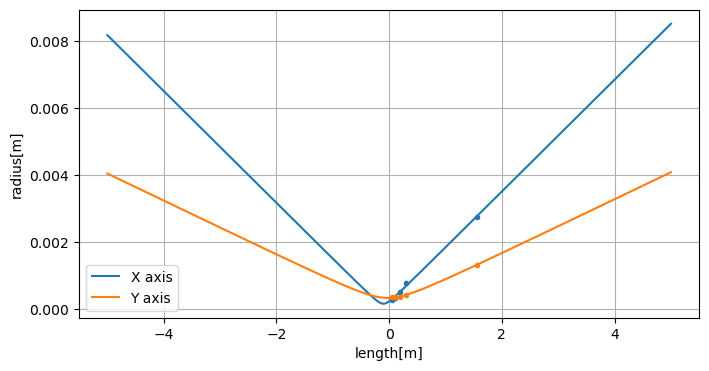

In [ ]:
zs = np.array([2,4,7.5,12,62])*25*1e-3 #[m]
# x方向(水平)とy方向(垂直)それぞれの直径を入力できるよう2つに分割
ws_x = np.array([521.4,657.4,1020.5,1562.7,5493.1])/2*1e-6 #[m]  # x方向
ws_y = np.array([748.8,711.9,730.5,818.4,2654.4])/2*1e-6 #[m]  # y方向

#任意の位置:zにおけるビーム径を出力
def waist(z, z0, w0):
    z_R = np.pi*w0**2/lam #Rayleigh length
    return w0*np.sqrt(1 + ((z-z0)/z_R)**2)

z = np.linspace(-5000e-3, 5000e-3, 10001)
initial_guess = [5, 1e-3]

# Curve fitting (x方向)
popt_x, pcov_x = curve_fit(waist, zs, ws_x, p0=initial_guess, maxfev=100000)
waist_position_0_x, w0_x = popt_x
zero_position_x = -waist_position_0_x
z_r_0_x = np.pi*1*popt_x[1]**2/lam

# Curve fitting (y方向)
popt_y, pcov_y = curve_fit(waist, zs, ws_y, p0=initial_guess, maxfev=100000)
waist_position_0_y, w0_y = popt_y
zero_position_y = -waist_position_0_y
z_r_0_y = np.pi*1*popt_y[1]**2/lam

print("--- X方向 ---")
print(f"waist position: {waist_position_0_x*1e3:.1f} [mm]")
print(f"beam waist: {w0_x*1e6:.1f} [um]")
print(f"rayleigh length: {z_r_0_x:.2f} [m]")
print(f"zero position from waist: {zero_position_x:.4f} [m]") #負:進行方向負, 正:進行方向正

print("\n--- Y方向 ---")
print(f"waist position: {waist_position_0_y*1e3:.1f} [mm]")
print(f"beam waist: {w0_y*1e6:.1f} [um]")
print(f"rayleigh length: {z_r_0_y:.2f} [m]")
print(f"zero position from waist: {zero_position_y:.4f} [m]") #負:進行方向負, 正:進行方向正

plt.figure(figsize=(8,4))
# x方向のプロット
plt.plot(z, waist(z, popt_x[0], popt_x[1]), label="X axis")
plt.plot(zs, ws_x, '.', color="C0")
# y方向のプロット
plt.plot(z, waist(z, popt_y[0], popt_y[1]), label="Y axis")
plt.plot(zs, ws_y, '.', color="C1")

plt.grid(True)
plt.xlabel("length[m]")
plt.ylabel("radius[m]")
plt.legend()
plt.show()

# a,fを変数とした時のウェイスト位置、半径、レイリー長のグラフ

In [ ]:
前回の結果を元に焦点距離fのレンズを位置aに置くとした時の、レンズ通過後のウェイストの位置・半径をABCD行列により計算する。
a,fを変数として、定義域を設定、ウェイスト位置・半径・レイリー長の関数を作る。
計算結果をそれぞれグラフで出力する。

・ウェイスト半径のグラフ

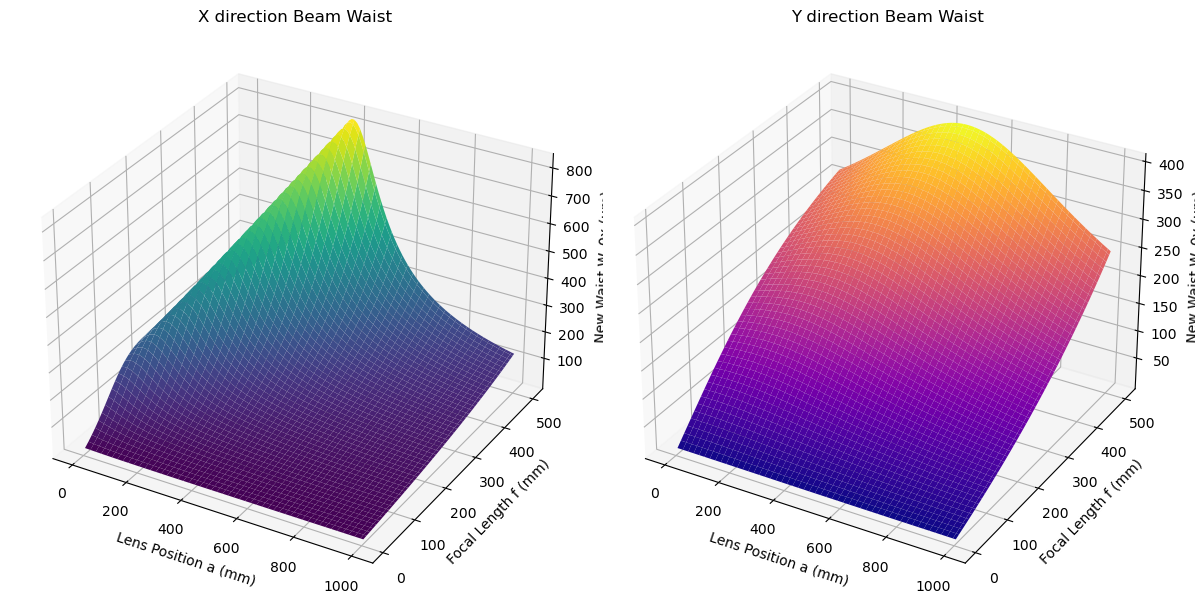

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. 前回のフィッティング結果を引き継ぐ
# ==========================================
w_0x = 162.6e-6      # X方向のビームウェスト半径 [m]
z_0x = -101.8e-3     # X方向のウェスト位置 [m]
w_0y = 334.7e-6      # Y方向のビームウェスト半径 [m]
z_0y = -24.7e-3           # （Y方向のウェスト位置も同様に e-3 などで書いてくださいね）
# lam = 1064e-9                # 波長は前回のものがそのまま使われます

# ==========================================
# 2. ガウシアンビームのレンズ変換関数の定義
# ==========================================
def new_waist_size(w_0, z_0, a, f):
    """レンズ通過後の新しいビームウェスト半径(W_0)を計算"""
    z_R = np.pi * w_0**2 / lam
    s = a - z_0  # 入射側ウェストからレンズまでの距離
    M = f / np.sqrt((s - f)**2 + z_R**2)  # 倍率
    return M * w_0

def new_waist_position_sin(w_0, z_0, a, f):
    """レンズ通過後の新しいビームウェストの絶対位置(Z_0)を計算"""
    z_R = np.pi * w_0**2 / lam
    s = a - z_0  # 入射側ウェストからレンズまでの距離
    # レンズから新しいウェストまでの距離 (s')
    s_prime = f + ((s - f) * f**2) / ((s - f)**2 + z_R**2)
    # グラフの座標系に合わせて絶対位置を返す
    return a + s_prime

# ==========================================
# 3. メッシュグリッドの作成と計算
# ==========================================
# a と f の範囲を設定 (※解像度を指定しないとエラーになるため、100分割と明記)
a_values = np.linspace(0e-2, 100e-2, 100)  # 0 cm 〜 100 cm
f_values = np.linspace(5e-3, 500e-3, 100)  # 5 mm 〜 500 mm
A, F = np.meshgrid(a_values, f_values)     # 2D グリッド作成

# 新しいビームウェイスト径(w_0x → W_0x)
W_0x_grid = new_waist_size(w_0x, z_0x, A, F)
W_0y_grid = new_waist_size(w_0y, z_0y, A, F)

# 新しいビームウェイストの位置(z_0x → Z_0x)
Z_0x_grid = new_waist_position_sin(w_0x, z_0x, A, F)
Z_0y_grid = new_waist_position_sin(w_0y, z_0y, A, F)

# 新しいレイリー長(z_Rx → Z_Rx)
Z_Rx_grid = np.pi * W_0x_grid**2 / lam
Z_Ry_grid = np.pi * W_0y_grid**2 / lam

# ==========================================
# 4. 3Dプロット
# ==========================================
fig = plt.figure(figsize=(12, 6))

# X方向のプロット
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(A * 1e3, F * 1e3, W_0x_grid * 1e6, cmap='viridis') # 単位を[um]に変更して見やすく
ax1.set_xlabel("Lens Position a (mm)")
ax1.set_ylabel("Focal Length f (mm)")
ax1.set_zlabel("New Waist W_0x (um)")
ax1.set_title("X direction Beam Waist")

# Y方向のプロット
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(A * 1e3, F * 1e3, W_0y_grid * 1e6, cmap='plasma')  # 単位を[um]に変更して見やすく
ax2.set_xlabel("Lens Position a (mm)")
ax2.set_ylabel("Focal Length f (mm)")
ax2.set_zlabel("New Waist W_0y (um)")
ax2.set_title("Y direction Beam Waist")

plt.tight_layout()
plt.show()

In [ ]:
・ウェイスト位置（レンズからの距離）のグラフ

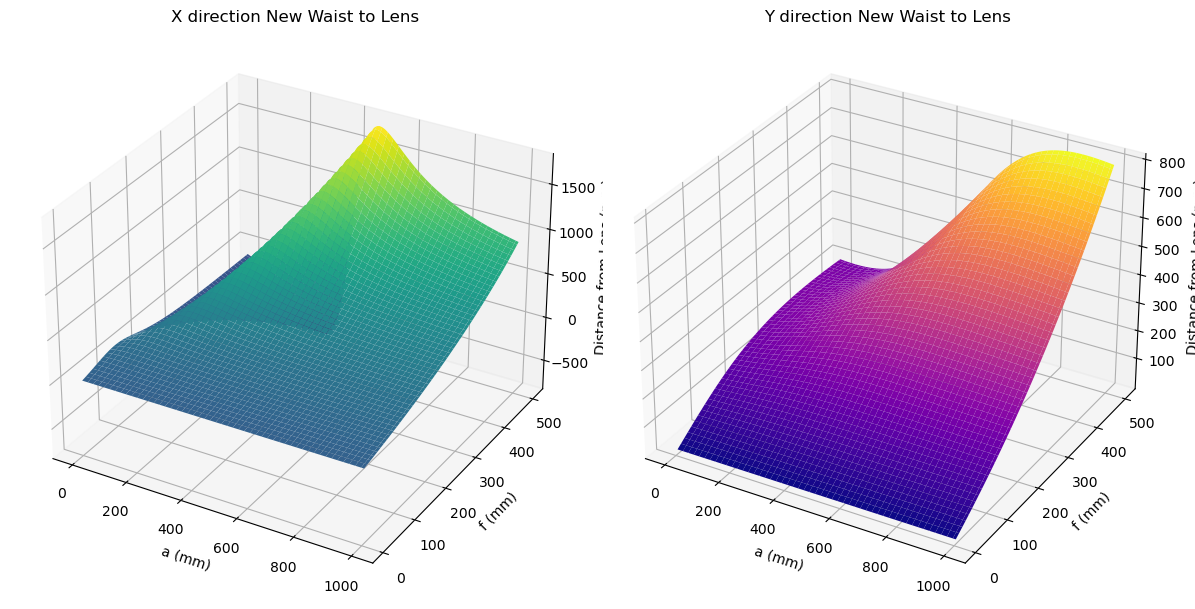

In [ ]:
# 3D プロット
fig = plt.figure(figsize=(12, 6))

# X方向のプロット
ax1 = fig.add_subplot(121, projection='3d')
# Z_0x_grid から A を引いて、レンズからの相対距離にする
ax1.plot_surface(A * 1e3, F * 1e3, (Z_0x_grid - A) * 1e3, cmap='viridis')  
ax1.set_xlabel("a (mm)")
ax1.set_ylabel("f (mm)")
ax1.set_zlabel("Distance from Lens (mm)")
ax1.set_title("X direction New Waist to Lens")

# Y方向のプロット
ax2 = fig.add_subplot(122, projection='3d')
# Z_0y_grid から A を引く
ax2.plot_surface(A * 1e3, F * 1e3, (Z_0y_grid - A) * 1e3, cmap='plasma')  
ax2.set_xlabel("a (mm)")
ax2.set_ylabel("f (mm)")
ax2.set_zlabel("Distance from Lens (mm)")
ax2.set_title("Y direction New Waist to Lens")

plt.tight_layout()
plt.show()# 3D プロット



In [ ]:
・レイリー長のグラフ

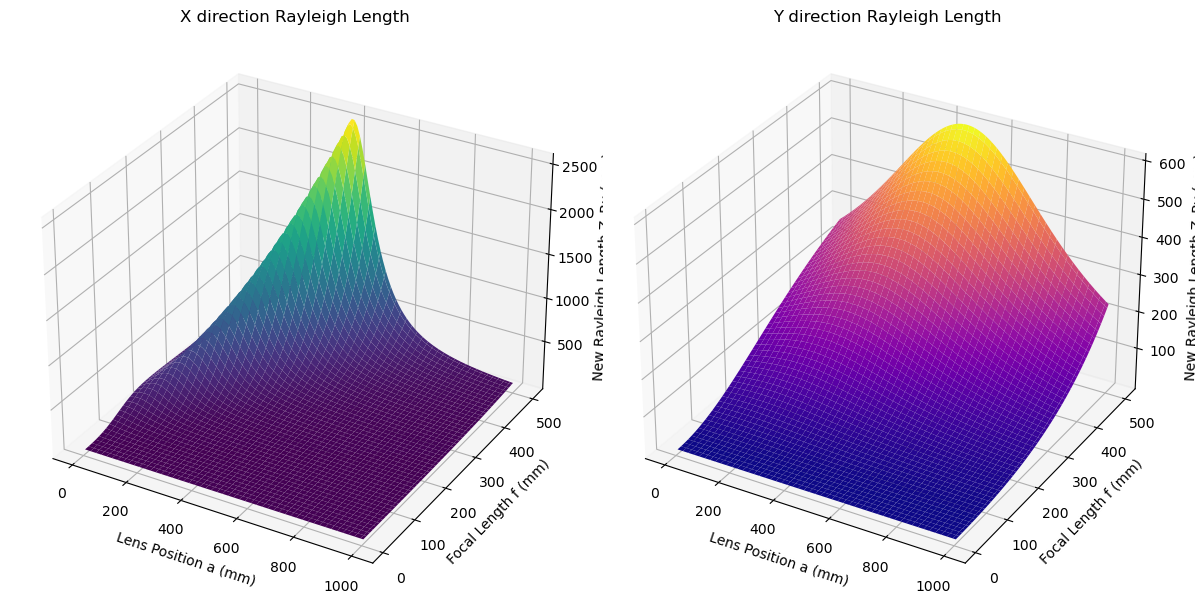

In [ ]:
# ==========================================
# 5. 3Dプロット (レイリー長)
# ==========================================
fig = plt.figure(figsize=(12, 6))

# X方向のプロット
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(A * 1e3, F * 1e3, Z_Rx_grid * 1e3, cmap='viridis')
ax1.set_xlabel("Lens Position a (mm)")
ax1.set_ylabel("Focal Length f (mm)")
ax1.set_zlabel("New Rayleigh Length Z_Rx (mm)")
ax1.set_title("X direction Rayleigh Length")

# Y方向のプロット
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(A * 1e3, F * 1e3, Z_Ry_grid * 1e3, cmap='plasma')
ax2.set_xlabel("Lens Position a (mm)")
ax2.set_ylabel("Focal Length f (mm)")
ax2.set_zlabel("New Rayleigh Length Z_Ry (mm)")
ax2.set_title("Y direction Rayleigh Length")

plt.tight_layout()
plt.show()

In [ ]:
レイリー長の範囲かつ、レンズの後ろの領域の長さ（＝実験で使える長さとする）を求める関数を作る

In [ ]:
def new_exp_size(w_0, z_0, a, f):
    Z_0 = new_waist_position_sin(w_0, z_0, a, f)
    Z_R = np.pi * new_waist_size(w_0, z_0, a, f)**2 / lam

    # NumPy配列に対して条件分岐を適用
    return np.where(
        (abs(Z_0) > Z_R) & (Z_0 < 0),  # Z_0が負でかつ |Z_0| > Z_R の場合
        0,  # 使用できないので 0 を返す
        np.where(
            Z_0 > Z_R,  # Z_0 が Z_R より大きい場合
            2 * Z_R,  # 2倍のレイリー長を使用
            Z_R + Z_0  # それ以外は Z_R + Z_0 を使用
        )
    )

In [ ]:
Esize_x_grid = new_exp_size(w_0x, z_0x, A, F)
Esize_y_grid = new_exp_size(w_0y, z_0y, A, F)

実験で実際に用いることのできる長さが1m以上である領域をグラフ化する

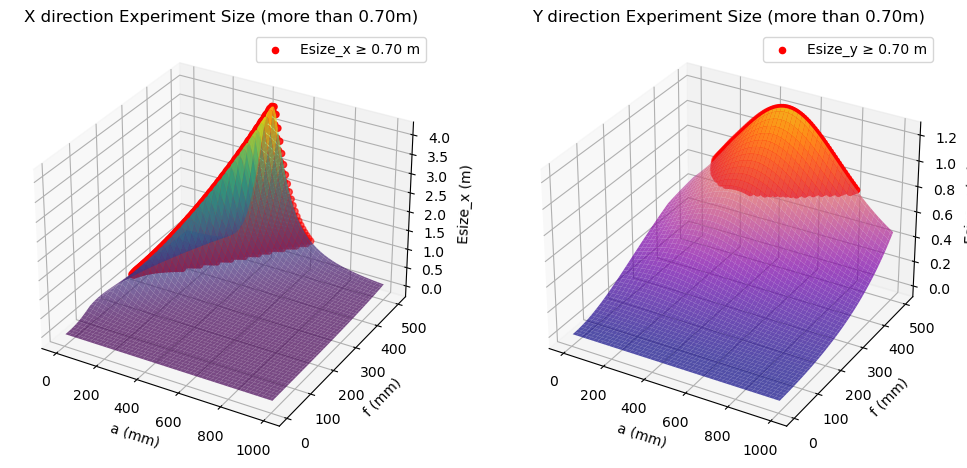

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 条件: 0.70 m  以上
threshold = 0.70 # m

# 条件を満たす (a, f) のインデックスを取得
mask_x = Esize_x_grid >= threshold
mask_y = Esize_y_grid >= threshold

# 3D プロット
fig = plt.figure(figsize=(12, 6))

# X方向のプロット
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(A * 1e3, F * 1e3, Esize_x_grid, cmap='viridis', alpha=0.7)  # 全体
ax1.scatter3D(A[mask_x] * 1e3, F[mask_x] * 1e3, Esize_x_grid[mask_x], color='r', label="Esize_x ≥ 0.70 m")  # 条件を満たす点
ax1.set_xlabel("a (mm)")
ax1.set_ylabel("f (mm)")
ax1.set_zlabel("Esize_x (m)")
ax1.set_title("X direction Experiment Size (more than 0.70m)")
ax1.legend()

# Y方向のプロット
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(A * 1e3, F * 1e3, Esize_y_grid, cmap='plasma', alpha=0.7)  # 全体
ax2.scatter3D(A[mask_y] * 1e3, F[mask_y] * 1e3, Esize_y_grid[mask_y], color='r', label="Esize_y ≥ 0.70 m")  # 条件を満たす点
ax2.set_xlabel("a (mm)")
ax2.set_ylabel("f (mm)")
ax2.set_zlabel("Esize_y (m)")
ax2.set_title("Y direction Experiment Size (more than 0.70m)")
ax2.legend()

plt.show()

上のグラフを2次元化する。a-f平面に射影して領域を分かりやすくする。

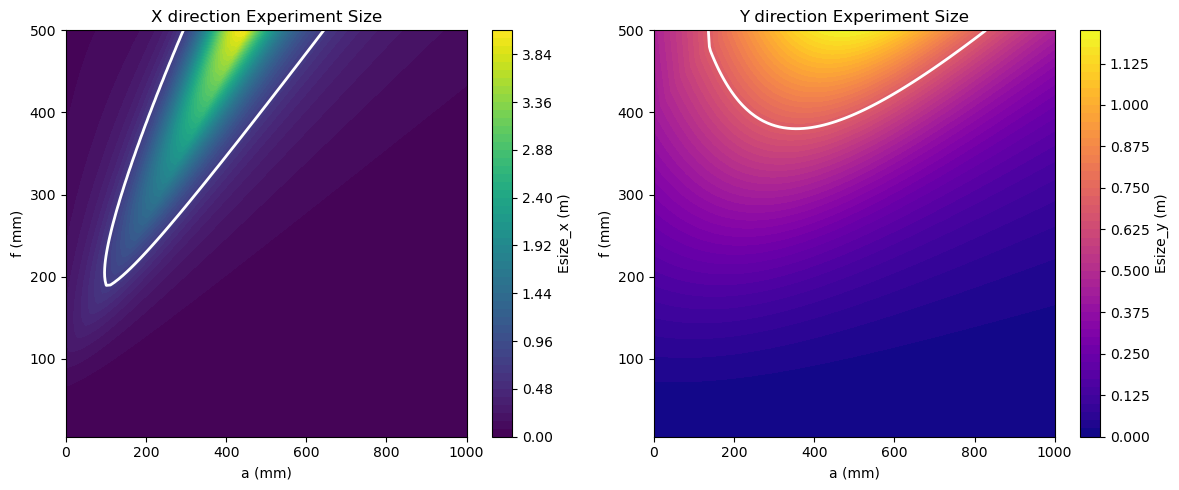

In [ ]:
# 条件: 1 m  以上
threshold = 0.70 # m

# 2D カラーマップを描画
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# X方向
c1 = ax[0].contourf(A * 1e3, F * 1e3, Esize_x_grid, levels=50, cmap="viridis")  # カラーマップ
ax[0].contour(A * 1e3, F * 1e3, Esize_x_grid, levels=[0.70], colors='white', linewidths=2)  # しきい値を白線で表示
ax[0].set_xlabel("a (mm)")
ax[0].set_ylabel("f (mm)")
ax[0].set_title("X direction Experiment Size")
fig.colorbar(c1, ax=ax[0], label="Esize_x (m)")

# Y方向
c2 = ax[1].contourf(A * 1e3, F * 1e3, Esize_y_grid, levels=50, cmap="plasma")  # カラーマップ
ax[1].contour(A * 1e3, F * 1e3, Esize_y_grid, levels=[0.70], colors='white', linewidths=2)  # しきい値を白線で表示
ax[1].set_xlabel("a (mm)")
ax[1].set_ylabel("f (mm)")
ax[1].set_title("Y direction Experiment Size")
fig.colorbar(c2, ax=ax[1], label="Esize_y (m)")

plt.tight_layout()
plt.show()

x,y方向の両方で条件を満たす範囲を図示する（上のグラフを１つにまとめる）

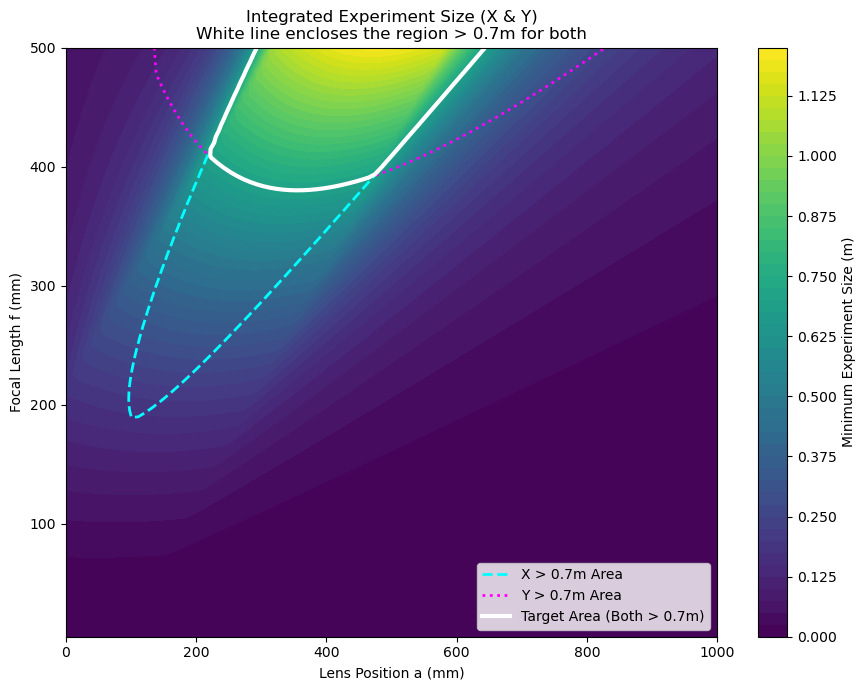

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 条件: 1 m  以上
threshold = 0.70 # m

# XとYの「短い方（ボトルネック）」の値を計算
# これが1.0m以上なら、XとYの両方が1.0m以上ということになります
min_Esize_grid = np.minimum(Esize_x_grid, Esize_y_grid)

fig, ax = plt.subplots(figsize=(9, 7))

# 背景カラーマップ：短い方の長さを表示
c = ax.contourf(A * 1e3, F * 1e3, min_Esize_grid, levels=50, cmap="viridis")
fig.colorbar(c, ax=ax, label="Minimum Experiment Size (m)")

# X方向だけのしきい値ライン（シアン色の破線）
ax.contour(A * 1e3, F * 1e3, Esize_x_grid, levels=[threshold], colors='cyan', linestyles='dashed', linewidths=2)

# Y方向だけのしきい値ライン（マゼンタ色の点線）
ax.contour(A * 1e3, F * 1e3, Esize_y_grid, levels=[threshold], colors='magenta', linestyles='dotted', linewidths=2)

# 【重要】両方が条件を満たす領域の境界（太い白線）
# この白線の内側が、今回の実験で実際に使える (a, f) の組み合わせです
ax.contour(A * 1e3, F * 1e3, min_Esize_grid, levels=[threshold], colors='white', linewidths=3)

ax.set_xlabel("Lens Position a (mm)")
ax.set_ylabel("Focal Length f (mm)")
ax.set_title("Integrated Experiment Size (X & Y)\nWhite line encloses the region > 0.7m for both")

# 凡例（Legend）を手動で追加して分かりやすくする
ax.plot([], [], color='cyan', linestyle='dashed', linewidth=2, label='X > 0.7m Area')
ax.plot([], [], color='magenta', linestyle='dotted', linewidth=2, label='Y > 0.7m Area')
ax.plot([], [], color='white', linewidth=3, label='Target Area (Both > 0.7m)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

# a, fの組み合わせの最適化

上の領域の範囲内でa,fの組み合わせを考えた。カップリング効率を考えた時、非点収差とビームの形状を改善しようとしたが、もとより楕円だったため、
円に近づけようとすると非点収差がひどくなった。そこで非点収差の方に重きを置いて（形状は楕円の長短比がスペック(2.09)より大きくならないようにした）、一番小さい値を取る組み合わせを採用した

In [ ]:
import numpy as np
import pandas as pd

# ==========================================
# 1. 探索範囲と条件の設定
# ==========================================
threshold_min = 0.50  # 最小 0.5m
threshold_max = 1.00  # 最大 1.0m

# a, f ともに 50mm 〜 1500mm まで 50mm 刻み
a_candidates = np.arange(50, 500, 50) * 1e-3
f_candidates = np.arange(50, 500, 50) * 1e-3

results = []

for a in a_candidates:
    for f in f_candidates:
        # --- X方向の計算 ---
        z0x = new_waist_position_sin(w_0x, z_0x, a, f)
        w0x = new_waist_size(w_0x, z_0x, a, f)
        zrx = np.pi * w0x**2 / lam
        start_x = max(0, z0x - zrx)
        end_x = z0x + zrx
        
        # --- Y方向の計算 ---
        z0y = new_waist_position_sin(w_0y, z_0y, a, f)
        w0y = new_waist_size(w_0y, z_0y, a, f)
        zry = np.pi * w0y**2 / lam
        start_y = max(0, z0y - zry)
        end_y = z0y + zry

        # --- 共通範囲（Overlap）の計算 ---
        overlap_start = max(start_x, start_y)
        overlap_end = min(end_x, end_y)
        overlap_len = max(0, overlap_end - overlap_start)

        # 指定した範囲に収まるものを抽出
        if threshold_min <= overlap_len <= threshold_max:
            results.append({
                'a(mm)': int(a * 1000),
                'f(mm)': int(f * 1000),
                '有効長(m)': overlap_len,
                '開始距離(mm)': overlap_start * 1000,
                '非点収差(mm)': abs(z0x - z0y) * 1000,
                'Xウェスト位置(mm)': z0x * 1000,
                'Yウェスト位置(mm)': z0y * 1000,
                'Xウェスト半径(um)': w0x * 1e6,
                'Yウェスト半径(um)': w0y * 1e6,
                '長短比': max(w0x/w0y, w0y/w0x)
            })

# ==========================================
# 2. 表の作成と表示
# ==========================================
df = pd.DataFrame(results)

if not df.empty:
    # 非点収差が少ない順、かつ有効長が長い順にソート
    df_sorted = df.sort_values(by=['非点収差(mm)', '有効長(m)'], ascending=[True, False])
    
    print(f"✅ 条件に合う組み合わせが {len(df)} 件見つかりました。")
    print("🌟 「非点収差」が少なく、ファイバーカップリングに有利な順に表示します：")
    
    # 設置に必要な情報を優先して表示
    display(df_sorted.head(20).round(1).reset_index(drop=True))
else:
    print("❌ 指定された範囲では条件を満たす組み合わせが見つかりませんでした。")

✅ 条件に合う組み合わせが 10 件見つかりました。
🌟 「非点収差」が少なく、ファイバーカップリングに有利な順に表示します：


,a(mm),f(mm),有効長(m),開始距離(mm),非点収差(mm),Xウェスト位置(mm),Yウェスト位置(mm),Xウェスト半径(um),Yウェスト半径(um),長短比
0,250,350,0.6,260.5,75.6,623.2,547.6,583.9,279.1,2.1
1,300,400,0.8,256.6,98.7,730.3,631.6,667.3,319.0,2.1
2,350,450,0.9,238.8,124.9,838.4,713.4,750.7,358.8,2.1
3,200,350,0.5,195.9,417.1,50.5,467.6,523.4,271.5,1.9
4,300,350,0.6,336.3,539.1,1171.0,631.9,515.7,283.2,1.8
5,250,400,0.7,187.5,544.8,-2.4,542.3,598.2,310.3,1.9
6,300,450,0.9,164.7,689.5,-75.7,613.7,673.0,349.0,1.9
7,350,400,0.8,340.3,704.1,1430.4,726.3,589.3,323.6,1.8
8,250,450,0.6,108.1,862.5,-338.9,523.6,528.9,335.8,1.6
9,400,450,1.0,331.5,891.1,1711.2,820.1,663.0,364.1,1.8


f=350のレンズは所有していないため、a=300, f=400を採用した。

以下、a=300, f=400の時の各値の詳細である。

In [ ]:
import numpy as np

# --- 設定値 ---
a_target = 300 * 1e-3  # [m]
f_target = 400 * 1e-3  # [m]

def calculate_setup_details(a, f):
    # X方向の計算
    z0x = new_waist_position_sin(w_0x, z_0x, a, f)
    w0x = new_waist_size(w_0x, z_0x, a, f)
    zrx = np.pi * w0x**2 / lam
    
    # Y方向の計算
    z0y = new_waist_position_sin(w_0y, z_0y, a, f)
    w0y = new_waist_size(w_0y, z_0y, a, f)
    zry = np.pi * w0y**2 / lam

    # 実験に使える範囲（レンズからの距離）
    start_x, end_x = max(0, z0x - zrx), z0x + zrx
    start_y, end_y = max(0, z0y - zry), z0y + zry
    
    # 共通範囲（Overlap）
    overlap_start = max(start_x, start_y)
    overlap_end = min(end_x, end_y)
    overlap_len = max(0, overlap_end - overlap_start)

    print(f"=== 実験セットアップ詳細 (a={a*1000:.0f}mm, f={f*1000:.0f}mm) ===")
    print(f"【X方向 (水平)】")
    print(f"  ウェスト位置 (Z0x): {z0x*1000:.1f} mm (レンズから)")
    print(f"  ウェスト径   (W0x): {w0x*1e6:.1f} um")
    print(f"  レイリー長   (ZRx): {zrx*1000:.1f} mm")
    print(f"  美味しい範囲      : {start_x*1000:.1f} mm ～ {end_x*1000:.1f} mm")
    
    print(f"\n【Y方向 (垂直)】")
    print(f"  ウェスト位置 (Z0y): {z0y*1000:.1f} mm (レンズから)")
    print(f"  ウェスト径   (W0y): {w0y*1e6:.1f} um")
    print(f"  レイリー長   (ZRy): {zry*1000:.1f} mm")
    print(f"  美味しい範囲      : {start_y*1000:.1f} mm ～ {end_y*1000:.1f} mm")
    
    print(f"\n【共通・総合評価】")
    print(f"  共通有効長        : {overlap_len:.3f} m")
    print(f"  共通範囲の場所    : {overlap_start*1000:.1f} mm ～ {overlap_end*1000:.1f} mm")
    print(f"  非点収差(ズレ)    : {abs(z0x-z0y)*1000:.1f} mm")
    print(f"  ウェスト径の比率  : {max(w0x/w0y, w0y/w0x):.2f} 倍")
    
    if overlap_len < 0.5:
        print("\n⚠️ 注意: 共通範囲が0.5mを切っています。")

# 実行
calculate_setup_details(a_target, f_target)

=== 実験セットアップ詳細 (a=300mm, f=400mm) ===
【X方向 (水平)】
  ウェスト位置 (Z0x): 730.3 mm (レンズから)
  ウェスト径   (W0x): 667.3 um
  レイリー長   (ZRx): 1641.2 mm
  美味しい範囲      : 0.0 mm ～ 2371.6 mm

【Y方向 (垂直)】
  ウェスト位置 (Z0y): 631.6 mm (レンズから)
  ウェスト径   (W0y): 319.0 um
  レイリー長   (ZRy): 375.0 mm
  美味しい範囲      : 256.6 mm ～ 1006.6 mm

【共通・総合評価】
  共通有効長        : 0.750 m
  共通範囲の場所    : 256.6 mm ～ 1006.6 mm
  非点収差(ズレ)    : 98.7 mm
  ウェスト径の比率  : 2.09 倍
